# Happy Customer Project

## Project Description
This project analyzes and predicts customer happiness using the **ACME-HappinessSurvey2020** dataset. The objective is to identify the most influential factors driving customer satisfaction and to build predictive models that help businesses proactively improve customer experience and retention.

This end-to-end data science project covers:
- Exploratory Data Analysis (EDA)
- Data preprocessing and feature engineering
- Model development and tuning
- Model evaluation and comparison
- Business recommendations based on insights


# Dataset Overview

- Dataset: **ACME-HappinessSurvey2020.csv**
- Observations: 126 customer responses
- Features: 6 survey-based attributes
- Target Variable: Binary happiness indicator  
  - `1` = Happy  
  - `0` = Unhappy  

### Feature Descriptions (1–5 Rating Scale)

- **X1** – Order delivered on time  
- **X2** – Order contents as expected  
- **X3** – Ordered everything wanted  
- **X4** – Paid a good price  
- **X5** – Satisfaction with courier  
- **X6** – App ease of ordering  

All features are ordinal ratings, making the dataset structured and suitable for classification modeling.

**Goal(s):**

Predict if a customer is happy or not based on the answers they give to questions asked.     

Company is interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data. Is there any question that they can remove in next survey?

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from statsmodels.stats.outliers_influence import variance_inflation_factor

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics


# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
# To build model for prediction
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To get diferent metric scores
from sklearn.metrics import (
     f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)


# To supress warnings
import warnings

warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
Review= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ACME-HappinessSurvey2020.csv')

In [5]:
df=Review.copy()

## **EDA**

- Observations
- Sanity checks

In [ ]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [ ]:
df.tail()

,Y,X1,X2,X3,X4,X5,X6
121,1,5,2,3,4,4,3
122,1,5,2,3,4,2,5
123,1,5,3,3,4,4,5
124,0,4,3,3,4,4,5
125,0,5,3,2,5,5,5


In [ ]:
df.shape


(126, 7)

* 126 rows and 7 columns

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Y       126 non-null    int64
 1   X1      126 non-null    int64
 2   X2      126 non-null    int64
 3   X3      126 non-null    int64
 4   X4      126 non-null    int64
 5   X5      126 non-null    int64
 6   X6      126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


* All column data type is integer and there are no null values.

In [ ]:
df.describe()

,Y,X1,X2,X3,X4,X5,X6
count,126.000,126.000,126.000,126.000,126.000,126.000,126.000
mean,0.548,4.333,2.532,3.310,3.746,3.651,4.254
std,0.500,0.800,1.115,1.023,0.876,1.148,0.809
min,0.000,1.000,1.000,1.000,1.000,1.000,1.000
25%,0.000,4.000,2.000,3.000,3.000,3.000,4.000
50%,1.000,5.000,3.000,3.000,4.000,4.000,4.000
75%,1.000,5.000,3.000,4.000,4.000,4.000,5.000
max,1.000,5.000,5.000,5.000,5.000,5.000,5.000


•	On time order delivery(X1) average rating is 4.33 and apps make ordering easy(X6) average rating is 4.25  
•	Expectation of content(X2) average rating is lowest among all rating which is 2.5.  
•	All ratings are between 1 and 5.


In [ ]:
df.isnull().sum()

,0
Y,0
X1,0
X2,0
X3,0
X4,0
X5,0
X6,0


In [ ]:
df.duplicated().sum()

np.int64(16)

* There is no null value in the data.
* 16 duplicate rows present in the data.

In [ ]:
df['Y'].value_counts(normalize=True)

,proportion
Y,
1,0.548
0,0.452


* About 55% of the customers are happy and 45% are unhappy.

In [ ]:
# Show unique values for X1–X5
for col in ['X1', 'X2', 'X3', 'X4', 'X5']:
    print(f'Unique values for {col}: {df[col].value_counts()}')

Unique values for X1: X1
5    65
4    40
3    20
1     1
Name: count, dtype: int64
Unique values for X2: X2
3    42
2    34
1    27
4    17
5     6
Name: count, dtype: int64
Unique values for X3: X3
3    55
4    33
5    17
2    14
1     7
Name: count, dtype: int64
Unique values for X4: X4
4    53
3    41
5    25
2     5
1     2
Name: count, dtype: int64
Unique values for X5: X5
4    50
5    31
3    22
2    16
1     7
Name: count, dtype: int64


* All review column rated between 1 to 5 which is discrete value, Column X1 didn't receive rating 2.

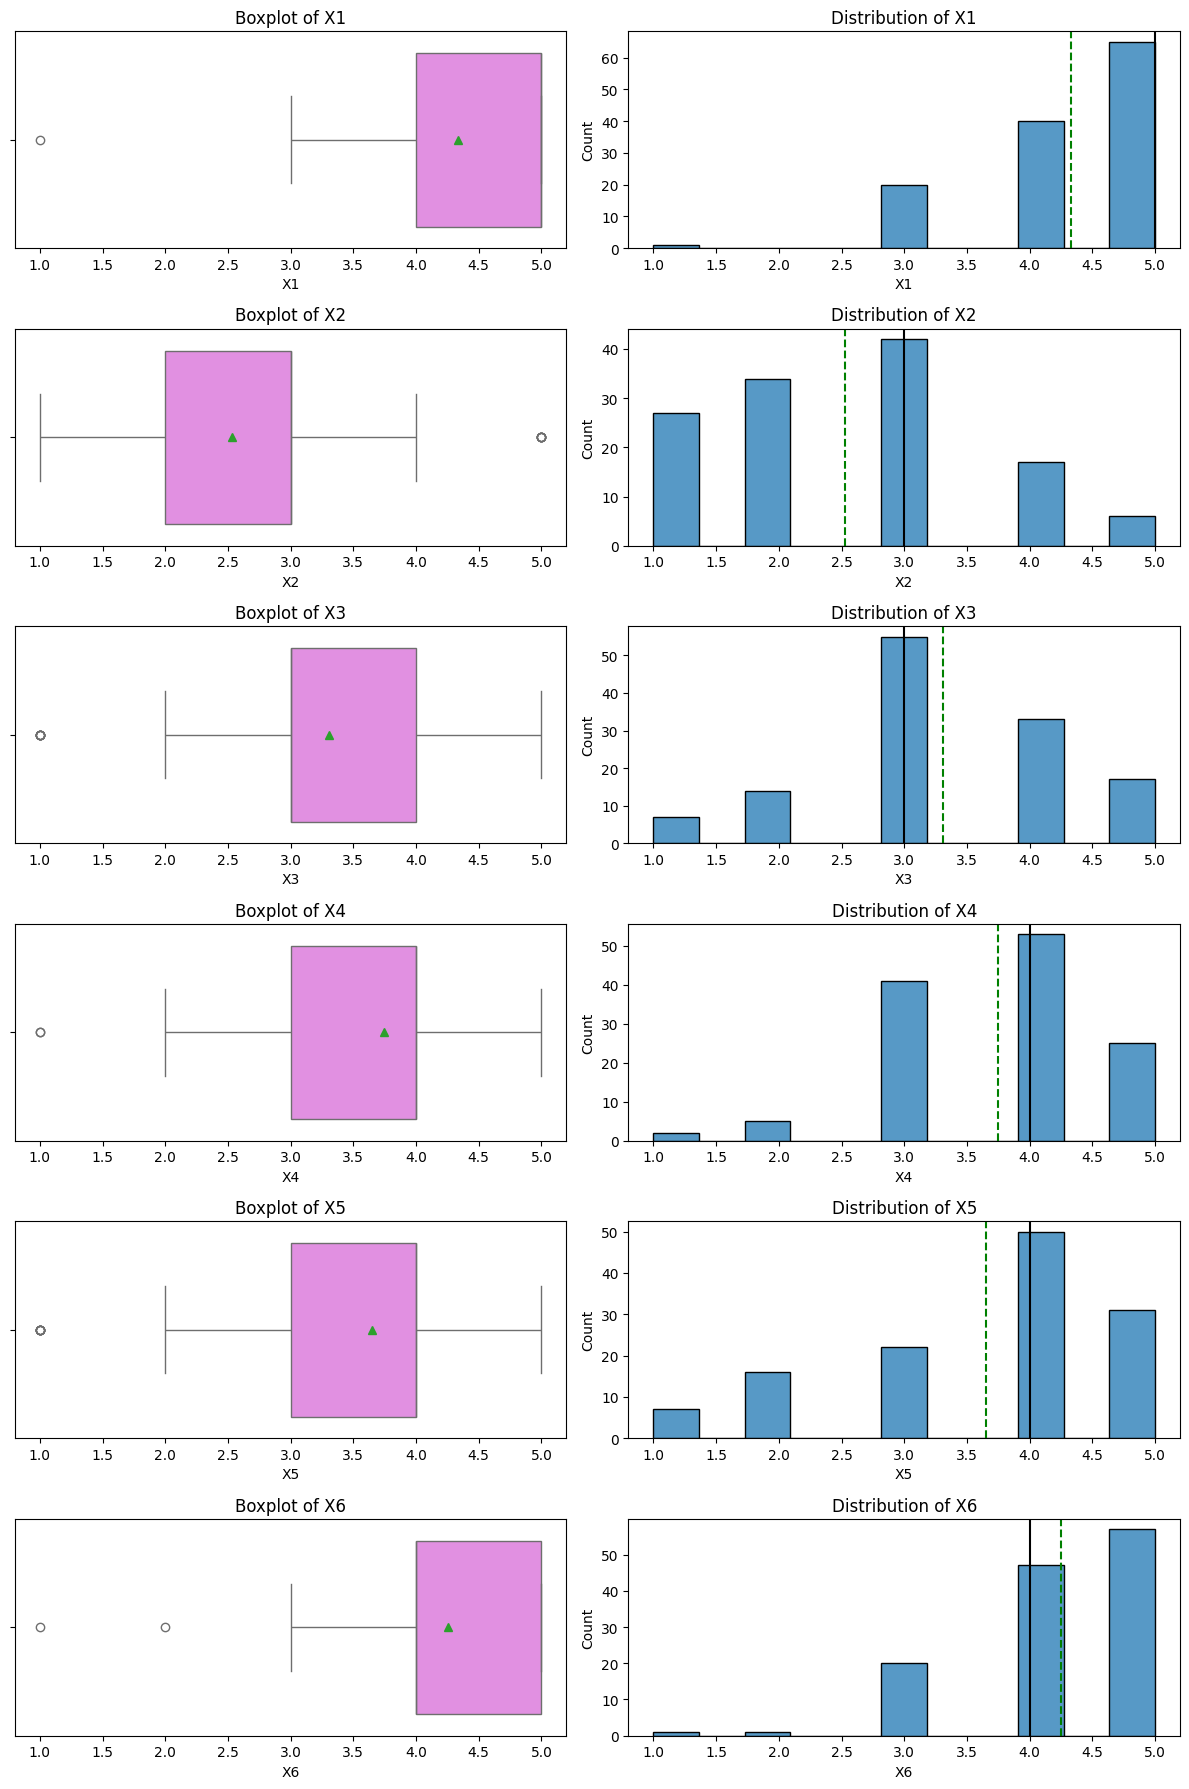

In [ ]:
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 18))
for i, feat in enumerate(features):
    sns.boxplot(data=df, x=feat, ax=axes[i, 0], showmeans=True, color="violet")
    axes[i, 0].set_title(f'Boxplot of {feat}')
    sns.histplot(data=df, x=feat, ax=axes[i, 1], kde=False)
    axes[i, 1].axvline(df[feat].mean(), color="green", linestyle="--")
    axes[i, 1].axvline(df[feat].median(), color="black", linestyle="-")
    axes[i, 1].set_title(f'Distribution of {feat}')

plt.tight_layout()
plt.show()


• Delivery timing (X1) and courier satisfaction (X5)’s majority responses are 4 and 5 ratings    
• Contents as Expected(X2) responses at 1 and 2 ratings   
• Other Features’ ratings are concentrated around 3 and 4 ratings  
• There are very few outliers in the data  


In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()

    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=60, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

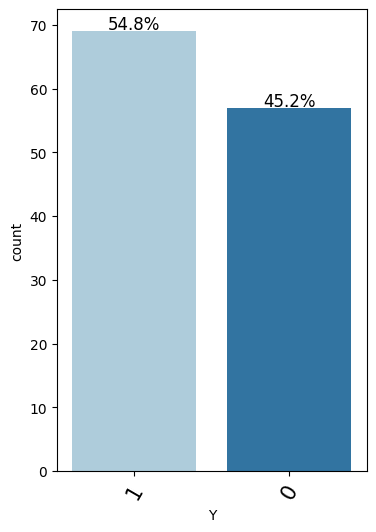

In [ ]:
labeled_barplot(df,"Y", perc=True)

* About 55% of the customers are happy and 45% are unhappy.

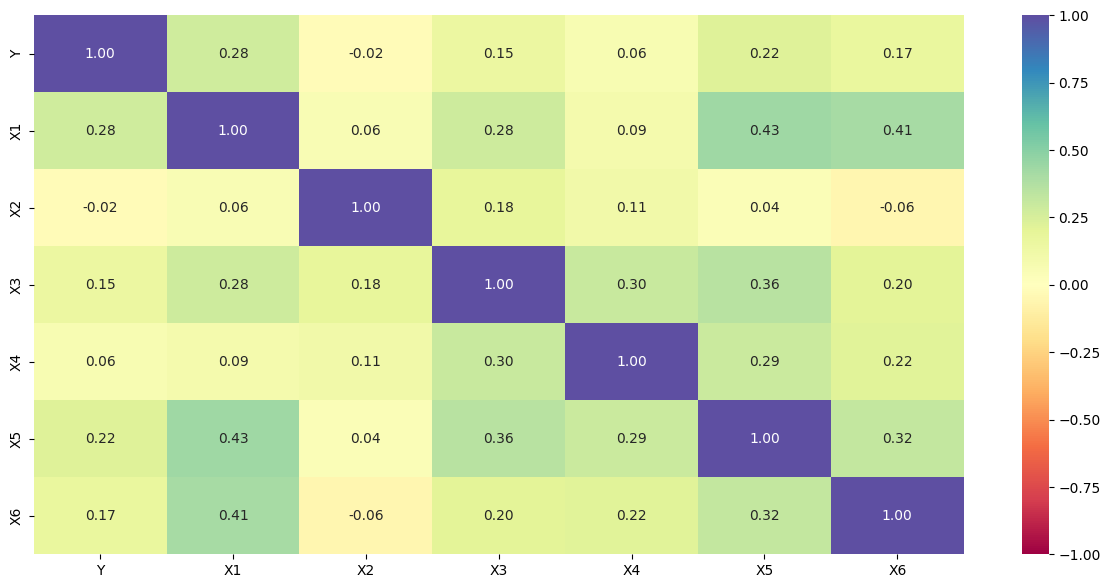

In [ ]:
plt.figure(figsize=(15, 7))
# Selecting only numerical features for correlation analysis
numerical_data = df.select_dtypes(include=np.number)
sns.heatmap(numerical_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

* There is no strong correlation between independent variables and dependent variable "y".  
* There is a positive correlation between X1 and X5, and X1 and X6 features which means when order delivery on time rating increases customer satisfaction with the courier service ratings also increases.


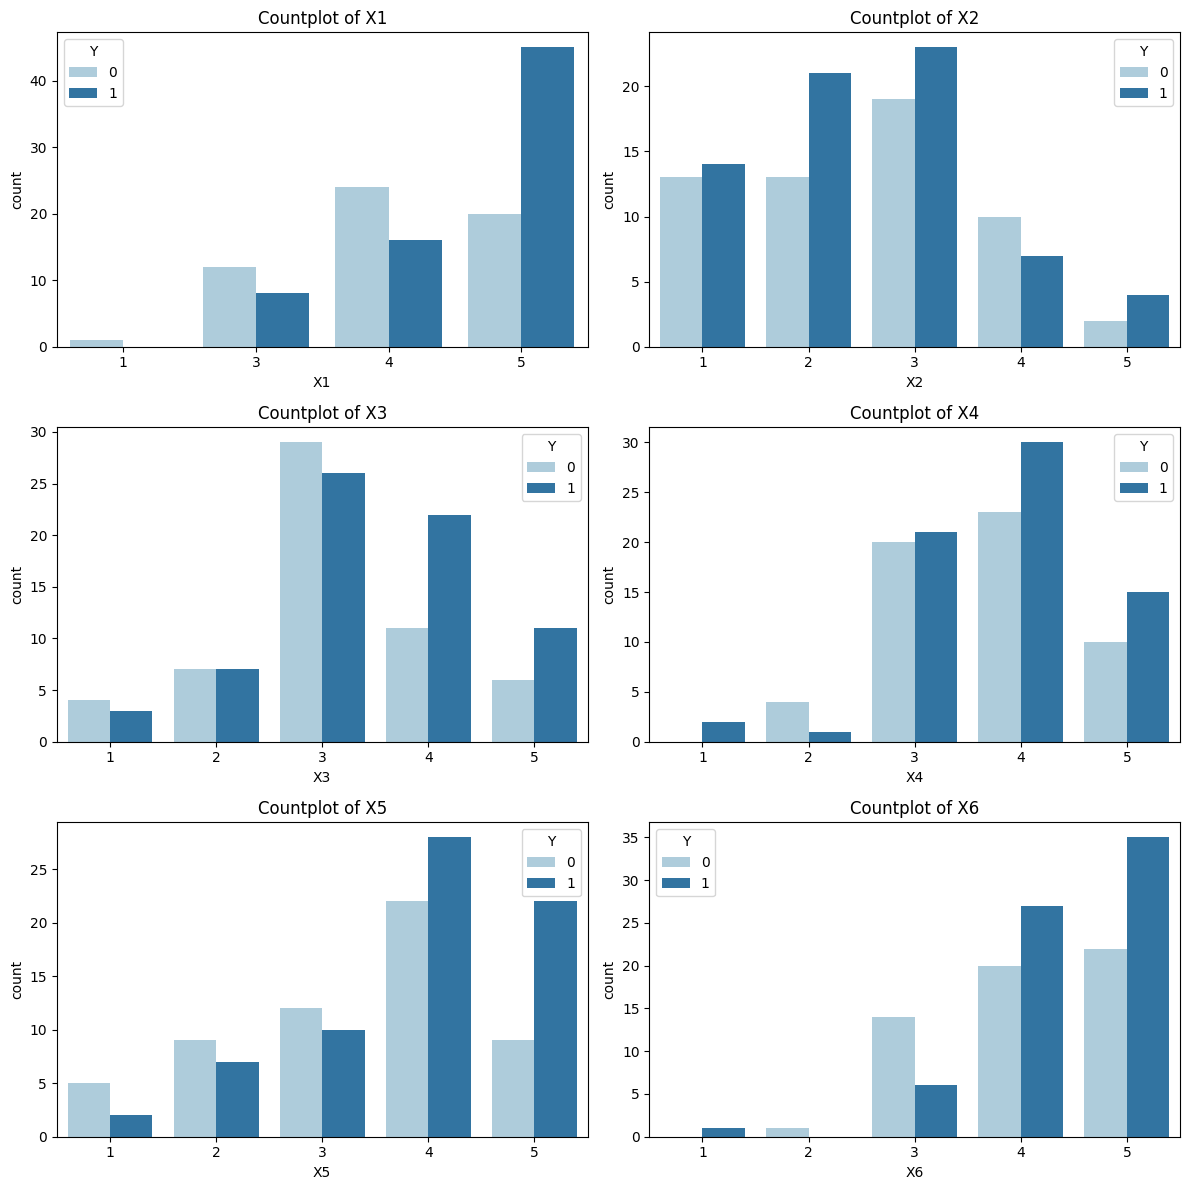

In [ ]:
features = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.ravel()

for ax, feat in zip(axes, features):
    sns.countplot(data=df, x=feat, hue='Y', ax=ax, palette='Paired', order=sorted(df[feat].unique()))
    ax.set_title(f'Countplot of {feat}')
    ax.legend(title='Y')

plt.tight_layout()
plt.show()


•	 X1, X4, X5 and X6 features received more positive ratings than other features.

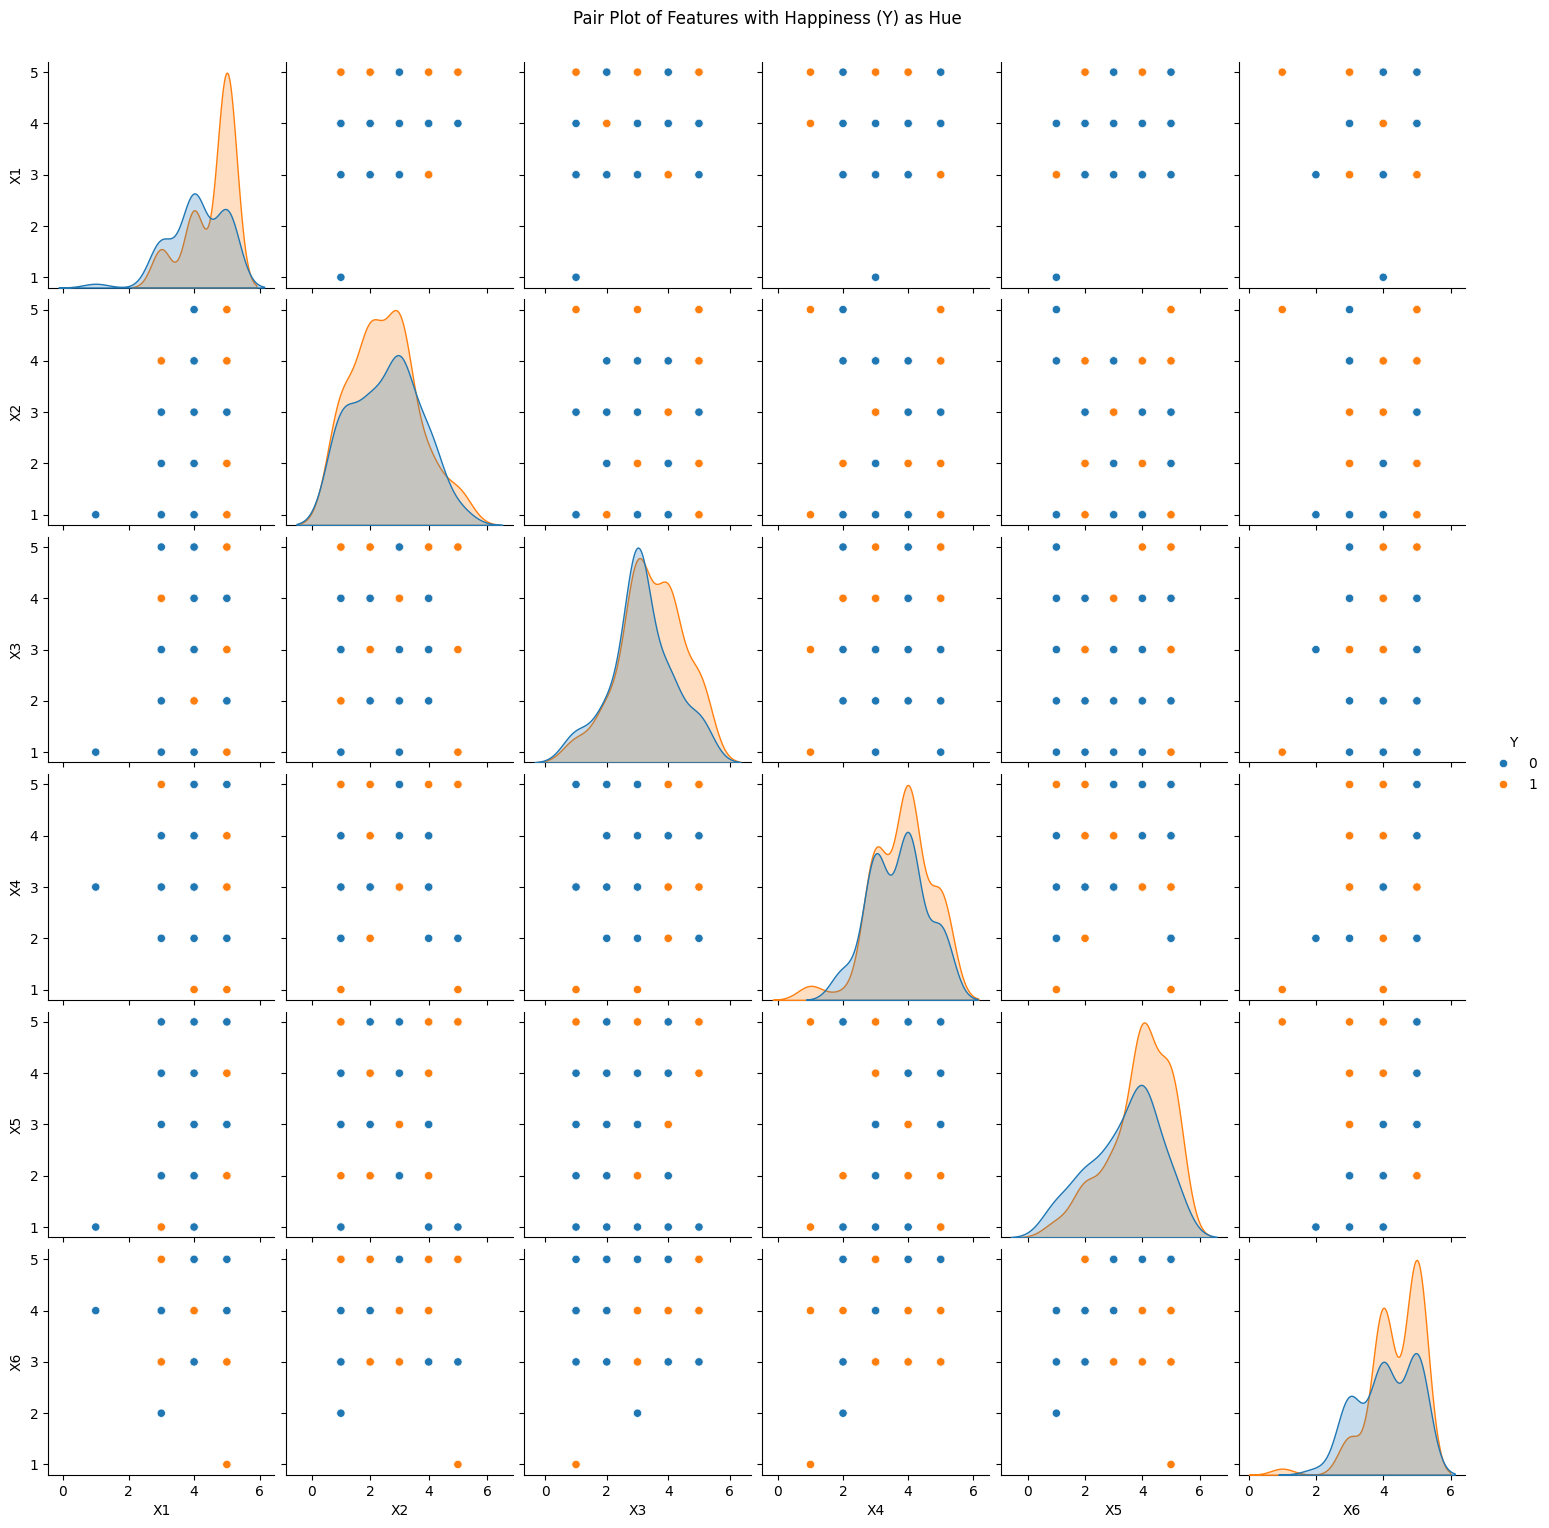

In [11]:
sns.pairplot(df, hue='Y', diag_kind='kde')
plt.suptitle('Pair Plot of Features with Happiness (Y) as Hue', y=1.02)
plt.show()

* Many features appear to have similar distributions for both happy and unhappy customers, as indicated by the overlapping KDEs on the diagonal. However, higher ratings for some X features might be slightly more concentrated among happy customers.

* A cluster of orange points (happy customers) in a region where X1 and X5 are both high, it suggests a positive correlation with happiness.

## **Approach 1**
We will first build logistic regression model and Decision tree model which is called baseline model to see how our data reacts to this model. It will help us establish a minimum performance threshold, allowing us to justify or decide against, using advanced models.

In [6]:
# specifying the independent  and dependent variables
X = df.drop(["Y"], axis=1)
Y = df["Y"]
# adding a constant to the independent variables
X = sm.add_constant(X)
# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y)

In [7]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 7)
Shape of test set :  (38, 7)
Percentage of classes in training set:
Y
1   0.545
0   0.455
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
1   0.553
0   0.447
Name: proportion, dtype: float64


* Using a Stratify parameter during train test split helped us to ensure training and testing sets have the same proportion of classes

In [8]:
df.shape

(126, 7)

In [9]:
df.head()

,Y,X1,X2,X3,X4,X5,X6
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


> **Checking Multicollinearity**
In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.

In [ ]:
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))

VIF values: 

const   57.187
X1       1.587
X2       1.100
X3       1.386
X4       1.201
X5       1.552
X6       1.341
dtype: float64



* There is no multicollinearity present in the data.

**Building a Logistic Regression model**

In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.08039
Time:                        23:41:05   Log-Likelihood:                -55.759
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.1357
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6713      1.849     -1.986      0.047      -7.295      -0.047
X1             0.2692      0.350      0.768      0.442      -0.418       0.956
X2            -0.0921      0.225     -0.410      0.6

* Negative values of the coefficient show that the probability of happy customer decreases with the increase of the corresponding attribute value.

* Positive values of the coefficient show that the probability of happy customer increases with the increase of the corresponding attribute value.

* p-value of a variable indicates if the variable is significant or not. If we consider the significance level to be 0.05 (5%), then any variable with a p-value less than 0.05 would be considered significant.

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

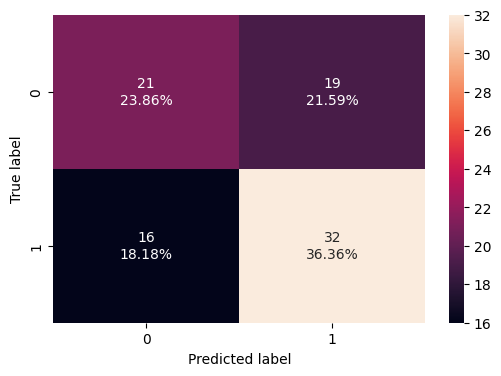

In [ ]:
confusion_matrix_statsmodels(lg, X_train, y_train)

Model evaluation criterion
Model can make wrong predictions such as:
•	Predicting that the customer is happy but in reality, the customer is not happy (FP)
•	Predicting the customer is not happy but in reality, the customer is happy (FN)
Which case is more important?
•	Company wants to predict happy customers so we will have to reduce FN which means we will maximize Recall.


In [ ]:
print("Training performance:")
model_performance_classification_statsmodels(lg, X_train, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.667,0.627,0.646


* The Recall of the model is ~0.67 and we will try to maximize it further
* We will have to remove high p-values

**Converting coefficients to odds to see which features are important**

* The coefficients ($\beta$s) of the logistic regression model are in terms of $log(odds)$ and to find the odds, we have to take the exponential of the coefficients
* Therefore, **$odds =  exp(\beta)$**
* The percentage change in odds is given as $(exp(\beta) - 1) * 100$

In [ ]:
# converting coefficients to odds
odds = np.exp(lg.params)

# finding the percentage change
perc_change_odds = (np.exp(lg.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

,const,X1,X2,X3,X4,X5,X6
Odds,0.025,1.309,0.912,1.282,1.213,1.330,1.081
Change_odd%,-97.456,30.896,-8.797,28.214,21.260,33.044,8.078


* Holding all other features constant a 1 unit change in X1 will increase the odds of gettiing happy customer by ~1.3 times or a ~31% increase in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X2 will decrease the odds of a booking getting canceled by ~0.91 times or a decrease of
~8.8% decrease in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X5 will increase the odds of gettiing happy customer by ~1.3 times or a ~33% increase in odds of booking getting canceled.

### Removing high p-value variables

In [ ]:
# initial list of columns
cols = X_train.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'X5']


* After dropping features one by one with higher P value, we have only one feature left X1.
* Our goal is inference (understanding relationships) so we will keep non-significant predictors.


In [ ]:
log_reg_model_train_perf = model_performance_classification_statsmodels(
    lg, X_train, y_train
)

print("Training performance:")
log_reg_model_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.667,0.627,0.646


In [ ]:
log_reg_model_test_perf = model_performance_classification_statsmodels(
    lg, X_test, y_test
)

print("Test performance:")
log_reg_model_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.579,0.714,0.600,0.652


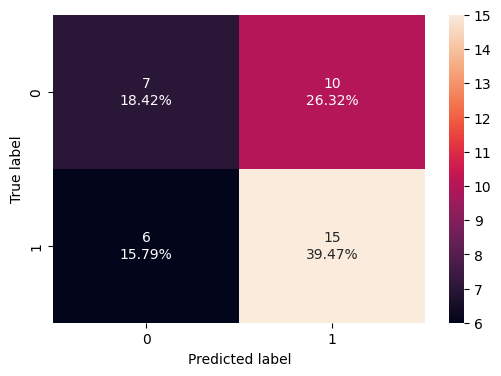

In [ ]:
confusion_matrix_statsmodels(lg, X_test, y_test)

•	Logistic Regression model gave recall that is little underfitting with 67% in training set and 71% in testing set which means model is very simple for the data but it generalized well. We can see if other models can maximize recall and accuracy.

•	According to Logistic Regression column X5 is very important feature followed by X1, X3, X4, X2 by looking at odds and change of odds in percentage. Column X6 is least likely to predict y variable according to this model.


### Building a Decision Tree model

In [ ]:
df.head()

,Y,X1,X2,X3,X4,X5,X6,X_mean
0,0,3,3,3,4,2,4,3.167
1,0,3,2,3,5,4,3,3.333
2,1,5,3,3,3,3,5,3.667
3,0,5,4,3,3,3,5,3.833
4,0,5,4,3,3,3,5,3.833


In [ ]:
X = df.drop(["Y"], axis=1)
Y = df["Y"]

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y
)

In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (88, 7)
Shape of test set :  (38, 7)
Percentage of classes in training set:
Y
1   0.545
0   0.455
Name: proportion, dtype: float64
Percentage of classes in test set:
Y
1   0.553
0   0.447
Name: proportion, dtype: float64


In [ ]:
Dtree = DecisionTreeClassifier(random_state=1, class_weight="balanced")
Dtree.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

In [ ]:
decision_tree_perf_train_without = model_performance_classification_statsmodels(
    Dtree, X_train, y_train
)
decision_tree_perf_train_without

,Accuracy,Recall,Precision,F1
0,0.932,0.875,1.000,0.933


* Decision tree tends to overfit so we will hyper tune it before giving it test data

* There is a huge disparity in performance of model on training set and test set, which suggests that the model is overfitting.
* We will do hyperparameter tuning to solve overfitting problem

In [ ]:
# importance of features in the tree building ( The importance of a feature is computed as the
#(normalized) total reduction of the criterion brought by that feature. It is also known as the Gini importance )

print (pd.DataFrame(Dtree.feature_importances_, columns = ["Imp"], index = X_train.columns).sort_values(by = 'Imp', ascending = False))

         Imp
X3     0.219
X_mean 0.190
X1     0.162
X2     0.137
X5     0.123
X6     0.106
X4     0.064


* According to decision tree most important feature is X2 which is 26% important and least important feacher is X4 which is 11% important.

### Hyperparameter Tuning

In [ ]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    #"max_depth": np.arange(1, 7, 1), # op-out because we have 126 rows only.
    "max_leaf_nodes": [2, 5, 10, 20, 30],
    "min_samples_split": [10, 20, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(recall_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', max_leaf_nodes=5,
                       min_samples_split=30, random_state=1)

* By using Grid search with cross validation, we found that class weight should be balanced, maximum depth should be 2, maximum leaf node should have 5 samples and minimum samples to do split is 30. Thay are the best parameters to get the best Recall.

In [ ]:
decision_tree_tune_perf_train = model_performance_classification_statsmodels(
    estimator, X_train, y_train
)
decision_tree_tune_perf_train

,Accuracy,Recall,Precision,F1
0,0.693,0.542,0.839,0.658


In [ ]:
decision_tree_tune_perf_test = model_performance_classification_statsmodels(
    estimator, X_test, y_test
)
decision_tree_tune_perf_test

,Accuracy,Recall,Precision,F1
0,0.605,0.381,0.800,0.516


* Hyperparameter tuned decision tree didn’t able to give best performance on recall but model’s precision score generalized well.


In [ ]:
feature_names = list(X_train.columns)
importances = estimator.feature_importances_
indices = np.argsort(importances)

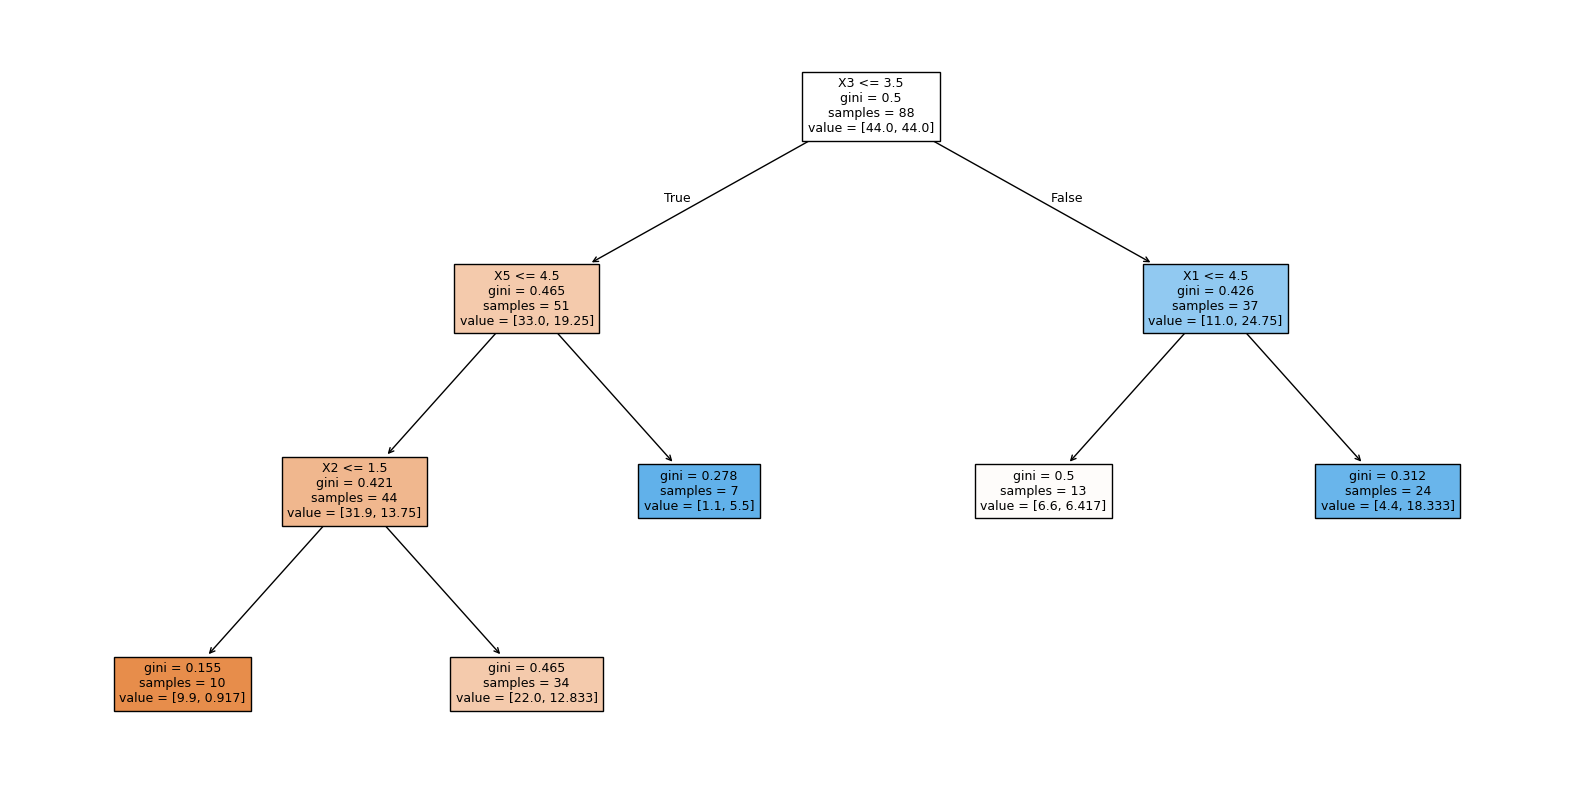

In [ ]:
plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.show()


* We can see gini impurity is high in two leaf nodes which is not good for our prediction.

## **Approach 2** : **Ensamble Techniques**

>> We will try other robust models to see if data generalize well and we can get best accuracy.
Since we have 126 rows, we can't split data into training, validation and testing sets. We will do hyper parameter tuning on training set and then at the end we will apply best model to testing set.


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\nTraining Performance:\n")
for name, model in models:
    model.fit(X_train, y_train)
    scores = accuracy_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))




Training Performance:

Bagging: 0.9318181818181818
Random forest: 0.9318181818181818
GBM: 0.9318181818181818
Adaboost: 0.7045454545454546
dtree: 0.9318181818181818
XGBoost: 0.9318181818181818


In [ ]:
models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Bagging", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=1, class_weight='balanced'), random_state=1)))
models.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
models.append(("GBM", GradientBoostingClassifier(random_state=1)))
models.append(("Adaboost", AdaBoostClassifier(random_state=1)))
models.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
models.append(("XGBoost", XGBClassifier(random_state=1)))

print("\nTesting Performance:\n")
for name, model in models:
    model.fit(X_test, y_test)
    scores = accuracy_score(y_test, model.predict(X_test))
    print("{}: {}".format(name, scores))




Testing Performance:

Bagging: 1.0
Random forest: 1.0
GBM: 1.0
Adaboost: 0.8421052631578947
dtree: 1.0
XGBoost: 1.0


* We will hyper parameter tuning on Random forest, Adaboost and Xgboost to get the best and generalize accuracy.

> **Hyper Parameter Tuning on Random Forest**

Best hyper‑parameters: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 5, 'max_depth': np.int64(6)}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.807   0.812      0.830 0.821

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.526   0.429      0.600 0.500

Confusion matrix – training set

Confusion matrix – test set


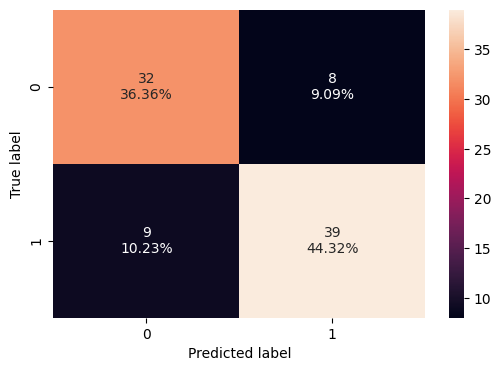

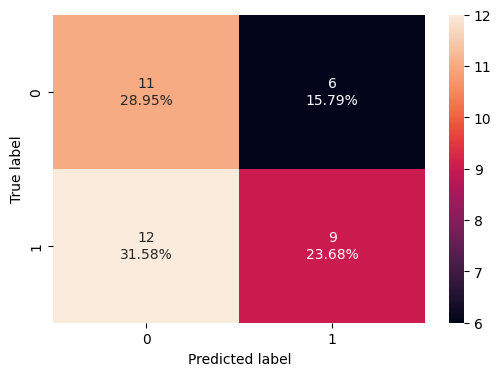

In [ ]:
# hyper–parameter tuning for a random‑forest classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
rf = RandomForestClassifier(random_state=42, class_weight="balanced")

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    "n_estimators": [50, 100, 200],
    "max_depth": np.arange(1, 7, 1),
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": [6, 5, 4],
}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(recall_score)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    scoring=scorer,
    cv=5,
    random_state=42,
    n_jobs=-1,
)
search.fit(X_train, y_train)

best_rf = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
rf_train_perf = model_performance_classification_statsmodels(best_rf, X_train, y_train)
rf_test_perf = model_performance_classification_statsmodels(best_rf, X_test, y_test)

print("\nRandom‑forest performance on training set:")
print(rf_train_perf)

print("\nRandom‑forest performance on test set:")
print(rf_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_statsmodels(best_rf, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_statsmodels(best_rf, X_test, y_test)

* Hyper tuned Random forest didn’t generalize well on testing data

> **Hyper parameter tuning on Adaboost**




Best hyper‑parameters: {'n_estimators': np.int64(70), 'learning_rate': 0.1}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.648   0.812      0.639 0.716

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.526   0.619      0.565 0.591

Confusion matrix – training set

Confusion matrix – test set


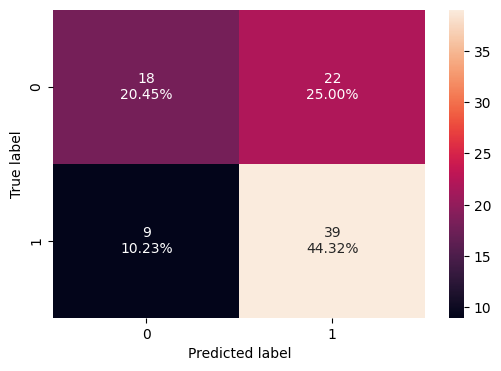

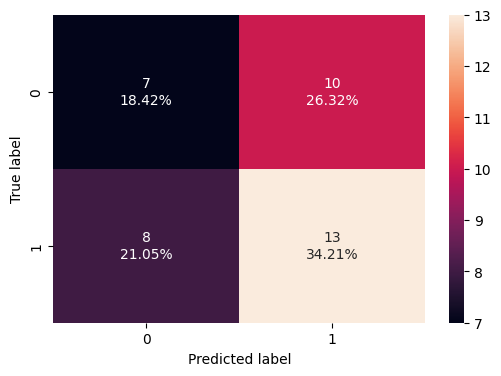

In [ ]:
# hyper–parameter tuning for a Adaboost classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
Ada_tuned = AdaBoostClassifier(random_state=1)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {'n_estimators': np.arange(10,100,10),
              'learning_rate': [1, 0.1, 0.5, 0.01], }



# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(accuracy_score)

search = RandomizedSearchCV(Ada_tuned, param_dist, cv=5, scoring=acc_scorer)
search.fit(X_train, y_train)

best_Ada_tuned = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
Ada_train_perf = model_performance_classification_statsmodels(best_Ada_tuned, X_train, y_train)
Ada_test_perf = model_performance_classification_statsmodels(best_Ada_tuned, X_test, y_test)

print("\nRandom‑forest performance on training set:")
print(Ada_train_perf)

print("\nRandom‑forest performance on test set:")
print(Ada_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_statsmodels(best_Ada_tuned, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_statsmodels(best_Ada_tuned, X_test, y_test)

> **Hyper parameter tuning on XGBoost**




Best hyper‑parameters: {'subsample': 0.7, 'scale_pos_weight': 5, 'n_estimators': np.int64(50), 'learning_rate': 0.1, 'gamma': 1}

Random‑forest performance on training set:
   Accuracy  Recall  Precision    F1
0     0.761   1.000      0.696 0.821

Random‑forest performance on test set:
   Accuracy  Recall  Precision    F1
0     0.526   0.762      0.552 0.640

Confusion matrix – training set

Confusion matrix – test set


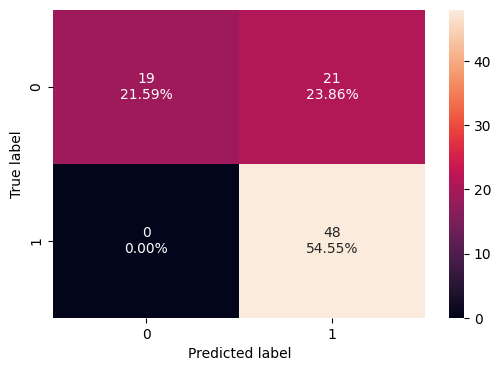

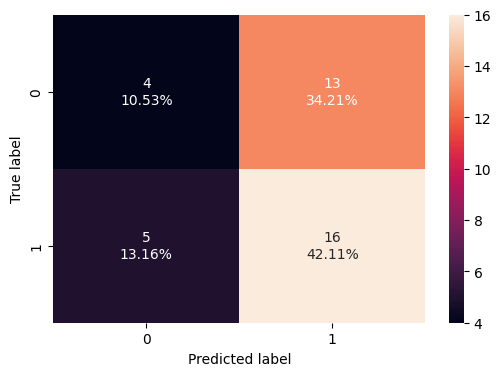

In [ ]:
# hyper–parameter tuning for a Bagging classifier and evaluation on
# both the training and the hold‑out test set

# base estimator
XGB_tuned = XGBClassifier(random_state=1)

# parameter grid / distribution (re‑use the one defined earlier if already present)
param_dist = {
    'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.05,0.1],
            'gamma':[1,3],
            'subsample':[0.7,0.9]}

# use recall as the scoring criterion since we care about catching happy customers
scorer = make_scorer(accuracy_score)

search = RandomizedSearchCV(XGB_tuned, param_dist, cv=5, scoring=scorer)
search.fit(X_train, y_train)

best_XGB_tuned = search.best_estimator_
print("Best hyper‑parameters:", search.best_params_)

# evaluate performance
XGB_train_perf = model_performance_classification_statsmodels(best_XGB_tuned, X_train, y_train)
XGB_test_perf = model_performance_classification_statsmodels(best_XGB_tuned, X_test, y_test)

print("\nRandom‑forest performance on training set:")
print(XGB_train_perf)

print("\nRandom‑forest performance on test set:")
print(XGB_test_perf)

# confusion matrices
print("\nConfusion matrix – training set")
confusion_matrix_statsmodels(best_XGB_tuned, X_train, y_train)
print("\nConfusion matrix – test set")
confusion_matrix_statsmodels(best_XGB_tuned, X_test, y_test)

* Many of the Ensemble Techniques (Decision Tree, Random Forest, XGBoost, AdaBoost tuned) exhibited significant overfitting. Their training performance was very high (e.g., F1-score > 0.8), but this dropped substantially on the test set (e.g., F1-score < 0.6). This indicates that these models learned the training data too well and failed to generalize to new, unseen data.

## **Approach 3**
* Now let's look at the Data Description:

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers
X1 = my order was delivered on time<br>
X2 = contents of my order was as I expected<br>
X3 = I ordered everything I wanted to order<br>
X4 = I paid a good price for my order<br>
X5 = I am satisfied with my courier<br>
X6 = the app makes ordering easy for me

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.
* If I would a be happy customer, I would give my rating average 3 for above survey. So we can use feature engineering to add column at the end, called avg_X. We can use this approach to predict y variable using effective threshold. Sometimes it can get biased if I am a happy customer and I am giving 1 rating to one category and 3 rating to remaining category.


In [ ]:

# Calculate the mean of X1 to X6 for each row
df['X_mean'] = df[['X1', 'X2', 'X3', 'X4', 'X5', 'X6']].mean(axis=1)


# Display the first few rows to verify
print(df.head())

   Y  X1  X2  X3  X4  X5  X6  X_mean
0  0   3   3   3   4   2   4   3.167
1  0   3   2   3   5   4   3   3.333
2  1   5   3   3   3   3   5   3.667
3  0   5   4   3   3   3   5   3.833
4  0   5   4   3   3   3   5   3.833


In [ ]:
# Features and target
X = df.drop(['Y', 'X1','X2', 'X3', 'X4', 'X5','X6'], axis=1)
y = df['Y']

# adding a constant to the independent variables
X = sm.add_constant(X)

# Train-test split (stratify to preserve class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [ ]:
logit2 = sm.Logit(y_train, X_train.astype(float))
lg2 = logit2.fit(disp=False)
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       86
Method:                           MLE   Df Model:                            1
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.01142
Time:                        21:51:15   Log-Likelihood:                -59.940
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.2393
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5256      1.486     -1.027      0.305      -4.438       1.387
X_mean         0.4731      0.408      1.160      0.246      -0.326       1.272


In [ ]:
print("Training performance:")
log_Xmean_train_perf= model_performance_classification_statsmodels(lg2, X_train, y_train)
log_Xmean_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.568,0.854,0.569,0.683


In [ ]:
log_Xmean_test_perf = model_performance_classification_statsmodels(
    lg2, X_test, y_test
)
print("Test performance:")
log_Xmean_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.658,0.905,0.633,0.745


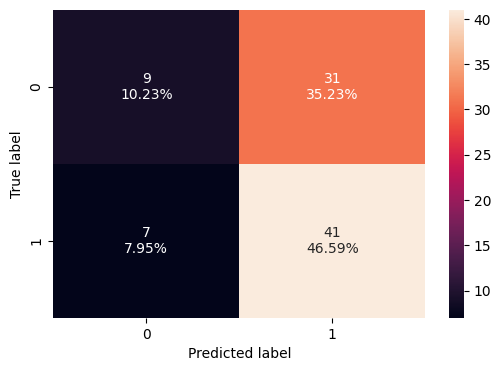

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg2, X_train, y_train)

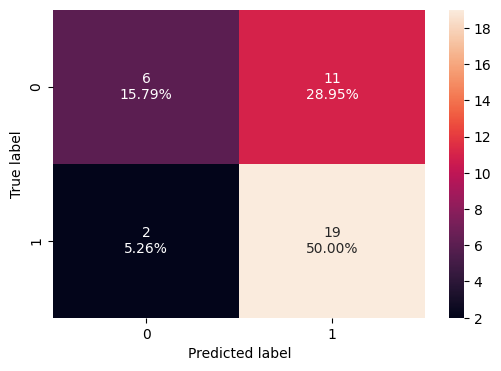

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg2, X_test, y_test)

* This model using avg_X as a independent variable to predict y variable did generalize well on training and testing set with 905 recall and 63% precision in testing set without overfitting.
* If company needs a simple model with less resources (time and CPU or GPU usage), they can use this model.


## **Final Approach**<br>
* We can see the robust models like decision tree, Random forest, Adaboost and Xgboost classifiers couldn’t generalize accuracy on both training and testing sets. The company will need to collect more data to analyze the results again.
* We can choose to go with logistic regression model. Furthermore, we can use precision-recall curve to choose best recall and precision for our model



### Precision-Recall Curve

In [ ]:
# specifying the independent  and dependent variables
X = df.drop(["Y"], axis=1)
Y = df["Y"]
# adding a constant to the independent variables
X = sm.add_constant(X)
# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.30, random_state=1, stratify=Y)

In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
lg = logit.fit(disp=False)
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.08039
Time:                        23:41:52   Log-Likelihood:                -55.759
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.1357
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6713      1.849     -1.986      0.047      -7.295      -0.047
X1             0.2692      0.350      0.768      0.442      -0.418       0.956
X2            -0.0921      0.225     -0.410      0.6

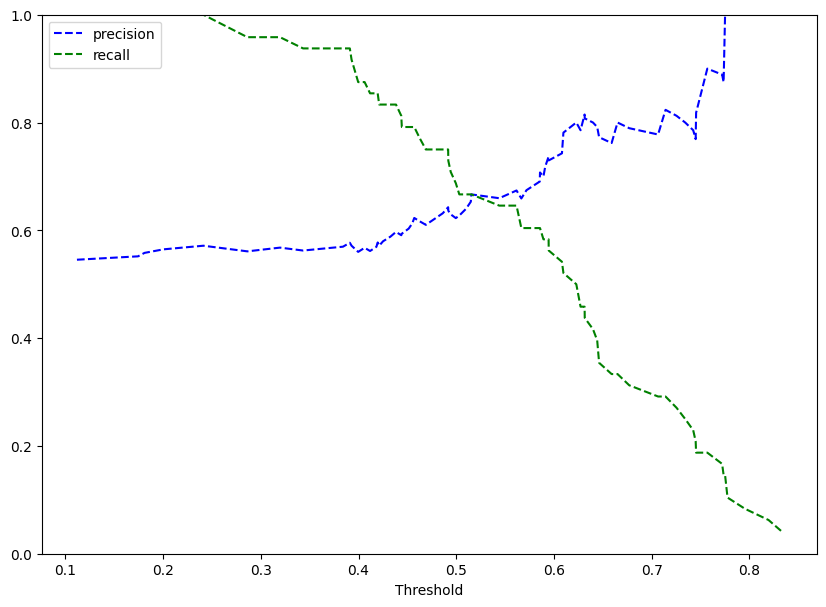

In [ ]:
y_scores = lg.predict(X_train)
prec, rec, tre = precision_recall_curve(y_train, y_scores)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [ ]:
# setting the threshold
optimal_threshold_curve = 0.45

> We will choose our optimal thresold 0.45 and use cross validation to optimize the model.



In [ ]:
# fitting the model on training set
logit = sm.Logit(y_train, X_train)
logit_final = logit.fit(threshold=optimal_threshold_curve, cv=5)
print(lg.summary())

Optimization terminated successfully.
         Current function value: 0.633620
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.08039
Time:                        23:42:00   Log-Likelihood:                -55.759
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.1357
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6713      1.849     -1.986      0.047      -7.295      -0.047
X1             0.2692      0.

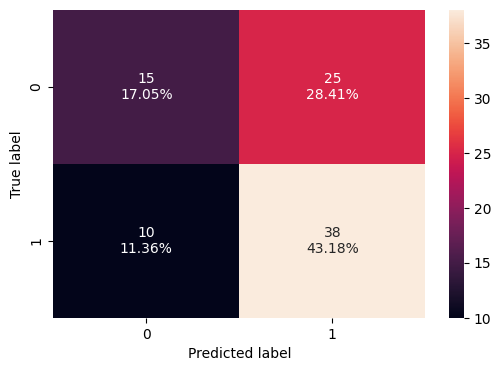

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(logit_final, X_train, y_train, threshold=optimal_threshold_curve)

In [ ]:
log_reg_model_train_perf_threshold_curve = model_performance_classification_statsmodels(
    logit_final, X_train, y_train, threshold=optimal_threshold_curve
)
print("Training performance:")
log_reg_model_train_perf_threshold_curve

Training performance:


,Accuracy,Recall,Precision,F1
0,0.602,0.792,0.603,0.685


In [ ]:
log_reg_model_test_perf_threshold_curve = model_performance_classification_statsmodels(
    logit_final, X_test, y_test, threshold=optimal_threshold_curve
)
print("Test performance:")
log_reg_model_test_perf_threshold_curve

Test performance:


,Accuracy,Recall,Precision,F1
0,0.579,0.810,0.586,0.680


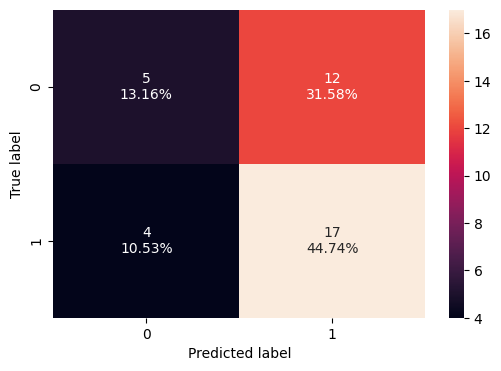

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(logit_final, X_test, y_test, threshold=optimal_threshold_curve)

* Logistic model with 0.45 threshold gave a best performance with 81% Recall and 55% precision. And both generalized well on training and testing data sets well.

## **Feature Elimination**
* The company is very interested in finding which questions/features are more important when predicting a customer’s happiness. Using a feature selection approach show them understand what is the minimal set of attributes/features that would preserve the most information about the problem while increasing predictability of the data they have. Is there any question that they can remove in our next survey?
* We can run feature importance on our logistic regression model and decide which features are less important

In [ ]:
# converting coefficients to odds
odds = np.exp(logit_final.params)

# finding the percentage change
perc_change_odds = (np.exp(logit_final.params) - 1) * 100

# removing limit from number of columns to display
pd.set_option("display.max_columns", None)

# adding the odds to a dataframe
pd.DataFrame({"Odds": odds, "Change_odd%": perc_change_odds}, index=X_train.columns).T

,const,X1,X2,X3,X4,X5,X6,X_mean
Odds,0.025,1.279,0.891,1.253,1.185,1.300,1.056,1.151
Change_odd%,-97.456,27.872,-10.904,25.252,18.459,29.970,5.581,15.056


* Holding all other features constant a 1 unit change in X5 will increase the odds of getting happy customers by ~1.33 times or a ~33% increase in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X1 will increase the odds of getting happy customers by ~1.3 times or a increase of ~31% decrease in odds of booking getting canceled.
* Holding all other features constant a 1 unit change in X2 will decrease the odds of getting happy customers by ~0.91 times or a ~9% decrease in odds of booking getting canceled.
* According to the model X5 and X1 features are most important features for being father away from 1 while X6 is the least important features for having Odds almost equal to 1
* Feature X2 decreases the probability of having a happy customer.
* X6 ('the app makes ordering easy for me') is the strongest candidate for removal in the next survey. Its impact on customer happiness, as measured by the odds ratio in logistic regression, is the smallest among all positive predictors (8% increase).

### Re-split Data without X6
Split the new DataFrame (without 'X6') into training and testing sets, ensuring stratification.


In [ ]:
df_no_x6 = df.drop(['X6'], axis=1)
X_no_x6 = df_no_x6.drop(['Y'], axis=1)
y_no_x6 = df_no_x6['Y']

X_train_no_x6, X_test_no_x6, y_train_no_x6, y_test_no_x6 = train_test_split(
    X_no_x6, y_no_x6, test_size=0.30, random_state=1, stratify=y_no_x6
)

print("Shape of X_train_no_x6:", X_train_no_x6.shape)
print("Shape of X_test_no_x6:", X_test_no_x6.shape)


Shape of X_train_no_x6: (88, 6)
Shape of X_test_no_x6: (38, 6)


In [ ]:
X_train_no_x6_const = sm.add_constant(X_train_no_x6)
X_test_no_x6_const = sm.add_constant(X_test_no_x6)

print("X_train_no_x6_const head:")
print(X_train_no_x6_const.head())
print("\nX_test_no_x6_const head:")
print(X_test_no_x6_const.head())

X_train_no_x6_const head:
     const  X1  X2  X3  X4  X5  X_mean
74   1.000   5   2   5   5   5   4.500
114  1.000   5   2   2   4   4   3.667
7    1.000   5   4   4   4   4   4.333
95   1.000   5   5   5   5   5   5.000
94   1.000   3   1   3   2   1   2.000

X_test_no_x6_const head:
     const  X1  X2  X3  X4  X5  X_mean
119  1.000   5   5   1   1   5   3.000
23   1.000   5   1   2   5   2   3.167
12   1.000   5   2   4   5   5   4.333
40   1.000   5   2   3   3   3   3.167
1    1.000   3   2   3   5   4   3.333


### Retrain Logistic Regression Model




In [ ]:
logit_no_x6 = sm.Logit(y_train_no_x6, X_train_no_x6_const.astype(float))
lg_no_x6 = logit_no_x6.fit(disp=False)
print(lg_no_x6.summary())

                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                   88
Model:                          Logit   Df Residuals:                       81
Method:                           MLE   Df Model:                            6
Date:                Wed, 04 Mar 2026   Pseudo R-squ.:                 0.08039
Time:                        21:51:45   Log-Likelihood:                -55.759
converged:                       True   LL-Null:                       -60.633
Covariance Type:            nonrobust   LLR p-value:                    0.1357
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.6713      1.849     -1.986      0.047      -7.295      -0.047
X1             0.1916      0.580      0.330      0.741      -0.946       1.329
X2            -0.1698      0.384     -0.442      0.6

In [ ]:
log_reg_model_train_perf_no_x6 = model_performance_classification_statsmodels(
    lg_no_x6, X_train_no_x6_const, y_train_no_x6, threshold=optimal_threshold_curve
)
print("Statsmodels Logistic Regression training performance (without X6) with optimal threshold:")
print(log_reg_model_train_perf_no_x6)

Statsmodels Logistic Regression training performance (without X6) with optimal threshold:
   Accuracy  Recall  Precision    F1
0     0.602   0.792      0.603 0.685


In [ ]:
log_reg_model_test_perf_no_x6 = model_performance_classification_statsmodels(
    lg_no_x6, X_test_no_x6_const, y_test_no_x6, threshold=optimal_threshold_curve
)
print("Statsmodels Logistic Regression test performance (without X6) with optimal threshold:")
print(log_reg_model_test_perf_no_x6)

Statsmodels Logistic Regression test performance (without X6) with optimal threshold:
   Accuracy  Recall  Precision    F1
0     0.579   0.810      0.586 0.680




*   This Logistic Regression model with identified optimal threshold, provides a stable and interpretable solution, particularly valuable for maximizing recall. The fact that removing X6 did not degrade performance reinforces that this feature is likely less important for predicting customer happiness.
*   Further analysis could involve optimizing the threshold more specifically for the test set to potentially find a better balance between precision and recall, depending on business needs.
*   The stability of performance after removing X6 suggests that this question could potentially be removed from future surveys without significant loss of predictive power for this specific model, simplifying data collection.

## **Comparing all the models**

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [ log_reg_model_train_perf.T,
      decision_tree_tune_perf_train.T,
      rf_train_perf.T,
      Ada_train_perf.T,
      XGB_train_perf.T,
      log_Xmean_train_perf.T,
      log_reg_model_train_perf_threshold_curve.T,
      log_reg_model_train_perf_no_x6.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Logistic Regression",
    "Tuned Decision Tree Classifier",
    "Tuned Random Forest Classifier",
    "Tuned Adaboost Classifier",
    "Tuned XGBoost Classifier",
    "Logistic Regression with avg_X",
    "Logistic Regression with optimal threshold",
    "Logistic Regression without X6",
    ]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Logistic Regression,Tuned Decision Tree Classifier,Tuned Random Forest Classifier,Tuned Adaboost Classifier,Tuned XGBoost Classifier,Logistic Regression with avg_X,Logistic Regression with optimal threshold,Logistic Regression without X6
Accuracy,0.602,0.693,0.807,0.648,0.761,0.568,0.602,0.602
Recall,0.667,0.542,0.812,0.812,1.000,0.854,0.792,0.792
Precision,0.627,0.839,0.830,0.639,0.696,0.569,0.603,0.603
F1,0.646,0.658,0.821,0.716,0.821,0.683,0.685,0.685


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [ log_reg_model_test_perf.T,
      decision_tree_tune_perf_test.T,
      rf_test_perf.T
      ,Ada_test_perf.T
      ,XGB_test_perf.T
      ,log_Xmean_test_perf.T
      ,log_reg_model_test_perf_threshold_curve.T
      ,log_reg_model_test_perf_no_x6.T
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Logistic Regression",
    "Tuned Decision Tree Classifier",
    "Tuned Random Forest Classifier",
    "Tuned Adaboost Classifier",
    "Tuned XGBoost Classifier",
    "Logistic Regression with avg_X",
    "Logistic Regression with optimal threshold",
    "Logistic Regression without X6",
    ]
print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,Logistic Regression,Tuned Decision Tree Classifier,Tuned Random Forest Classifier,Tuned Adaboost Classifier,Tuned XGBoost Classifier,Logistic Regression with avg_X,Logistic Regression with optimal threshold,Logistic Regression without X6
Accuracy,0.579,0.605,0.526,0.526,0.526,0.658,0.579,0.579
Recall,0.714,0.381,0.429,0.619,0.762,0.905,0.810,0.810
Precision,0.600,0.800,0.600,0.565,0.552,0.633,0.586,0.586
F1,0.652,0.516,0.500,0.591,0.640,0.745,0.680,0.680


# **Comparison of Model Effectiveness and Generalization**

### Overfitting Tendencies
- Many of the advanced models (Decision Tree, Random Forest, XGBoost, AdaBoost tuned) exhibited significant overfitting. Their training performance was very high (e.g., F1-score > 0.8), but this dropped substantially on the test set (e.g., F1-score < 0.6). This indicates that these models learned the training data too well and failed to generalize to new, unseen data.

### Logistic Regression Models
- The Logistic Regression model showed much better generalization. The difference between training and test set metrics was relatively small, suggesting they are not overfitting. Although their raw performance metrics (Accuracy, F1-score) are not as high as the overfit training scores of other models, their consistent performance makes them more reliable.

### Impact of X_mean Feature
- The Logistic Regression using only X_mean as a predictor achieved a remarkable recall of **0.905** on the test set. This highlights the potential simplicity in predicting happiness if an aggregate score is sufficiently informative.

### Optimal Threshold Application
- Applying an optimal threshold (**0.45**) to the Logistic Regression model (with all features) significantly boosted recall on the test set to **0.810**, while maintaining a reasonable F1-score of **0.680**. This demonstrates the importance of threshold tuning for specific optimization goals.

## Final Model Selection
- Logistic Regression with all features and an optimal threshold of **0.45** performed strongly with a test recall of **0.810** and a slightly better precision of **0.59**, offering a good balance.
- Strong and consistent results across both training and testing datasets Indicates low overfitting and good bias–variance balance
- The model achieved the best balance between predictive performance, interpretability, and business applicability.
   Model coefficients directly explain how each feature affects customer happiness.


# **Feature Importance Insights**

### Most Important Features
* Based on the Logistic Regression (which offers interpretable coefficients), X5 (courier satisfaction) and X1 (on-time delivery) are the most important features positively impacting customer happiness.
* X3 (ordered everything wanted) and X4 (good price) are also significant.
* X2 ('contents as expected') is important, albeit negatively correlated, indicating it's still a significant factor in dissatisfaction.
* The Decision Tree identified X2 (0.260), X3 (0.219), and X1 (0.162) as the most important features.

### Question to Remove
* X6 ('the app makes ordering easy for me') is the strongest candidate for removal in the next survey. Its impact on customer happiness, as measured by the odds ratio in logistic regression, is the smallest among all positive predictors (8% increase). More importantly, its removal from the Logistic Regression model resulted in virtually no change in performance metrics, indicating it provides minimal unique predictive value to this model.

### Important Business Consideration about Feature Elimination
Feature elimination does not imply that app usability is unimportant operationally. Rather, it indicates that within this dataset, app ease of ordering does not significantly differentiate happy and unhappy customers.


# **Business Insights and Recommendations**
* ### Enhance Courier Experience
The courier interaction is the final brand touchpoint and has the biggest impact on satisfaction. Couriers should be trained in customer communication and professionalism, their performance should be tracked using customer ratings, high satisfaction scores should be incentivized, and best practices from top performers should be replicated. This approach leads to the fastest and largest improvement in customer happiness.

* ### Improve Delivery Reliability
On-time delivery builds trust and reliability. Delivery routes should be optimized using data, real-time tracking updates should be provided, customers should be notified proactively about delays, and courier capacity should be increased during peak hours. Implementing these actions reduces frustration and strengthens customer trust.

* ### Reduce Expectation Gaps
Customers become unhappy when orders do not match their expectations. Product descriptions and images should be improved, inventory should be synced in real time, order verification should be added before shipment, and customers should be notified early about substitutions. These measures result in fewer complaints and a smoother customer experience.

* ### Increase Data Collection
The small dataset size (126 rows) limits the effectiveness of complex models and their ability to generalize. Collecting significantly more customer feedback data is crucial for improving predictive accuracy and model robustness.
